Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)
Importar o dataset MNIST via scikit-learn (fetch_openml('mnist_784')) ou via tensorflow.keras.datasets.mnist.
Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição das classes (balanceamento de dígitos de 0 a 9).
Gerar uma grade visual  de no mínimo 2 x 5 com matplotlib, exibindo exemplos de imagens de cada dígito junto com seus respectivos rótulos originais.
Inserir célula de texto interpretando a estrutura dos dados: explicar o significado da escala de intensidade de pixels (0 a 255) e como imagens bidimensionais (28 x 28) são representadas vetorialmente (784 features).


In [ ]:
#Carregando bibliotecas
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.base import clone

RANDOM_STATE = 42

Carregando o MNIST:

In [2]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data
y = mnist.target.astype(int)

Verificando estrutura dos dados:



In [3]:
print("X:", X.shape)
print("y:", y.shape)
print("Pixel mínimo:", X.min())
print("Pixel máximo:", X.max())

X: (70000, 784)
y: (70000,)
Pixel mínimo: 0
Pixel máximo: 255


Dimensionalidade dos dados

Foi confirmado que `X` possui shape `(70000, 784)` — 70 mil imagens,
cada uma "achatada" de 28x28 pixels em um vetor de 784 valores — e que
`y` possui shape `(70000,)`, um rótulo por imagem.

Verificando a quantidade de imagens de cada dígito:

In [4]:
distribuicao = (
    pd.Series(y)
    .value_counts()
    .sort_index()
)

display(
    pd.DataFrame({
        "Dígito": distribuicao.index,
        "Quantidade": distribuicao.values
    })
)

,Dígito,Quantidade
0,0,6903
1,1,7877
2,2,6990
3,3,7141
4,4,6824
5,5,6313
6,6,6876
7,7,7293
8,8,6825
9,9,6958


Antes de treinar qualquer modelo, é importante confirmar que as classes(dígitos 0 a 9) estão razoavelmente balanceadas. Isso justifica o uso da
acurácia como métrica confiável mais adiante — em um dataset desbalanceado, a acurácia pode enganar (um modelo que só "chuta" a classe majoritária
teria acurácia alta sem aprender nada).

In [7]:
classes, contagens = np.unique(y, return_counts=True)
for c, n in zip(classes, contagens):
    print(f"Dígito {c}: {n} amostras")

Dígito 0: 6903 amostras
Dígito 1: 7877 amostras
Dígito 2: 6990 amostras
Dígito 3: 7141 amostras
Dígito 4: 6824 amostras
Dígito 5: 6313 amostras
Dígito 6: 6876 amostras
Dígito 7: 7293 amostras
Dígito 8: 6825 amostras
Dígito 9: 6958 amostras


Gráfico de distribuição das classes:

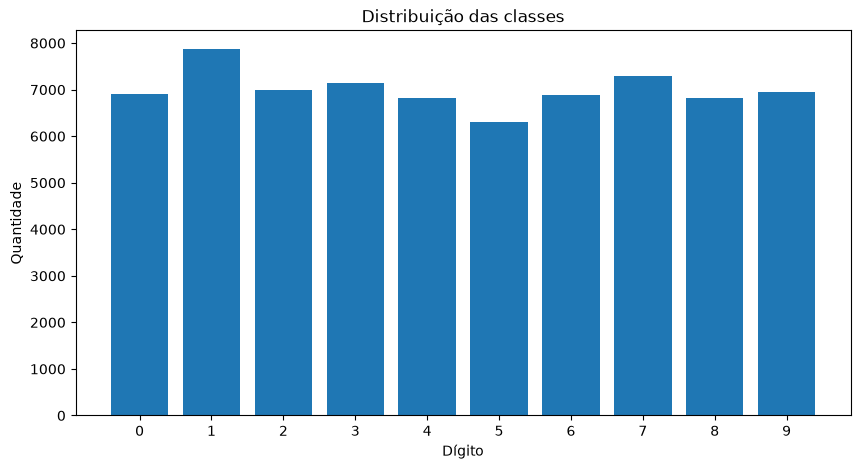

In [5]:
plt.figure(figsize=(10, 5))

plt.bar(
    distribuicao.index.astype(str),
    distribuicao.values
)

plt.xlabel("Dígito")
plt.ylabel("Quantidade")
plt.title("Distribuição das classes")

plt.show()

Mostra um exemplo de cada classe:

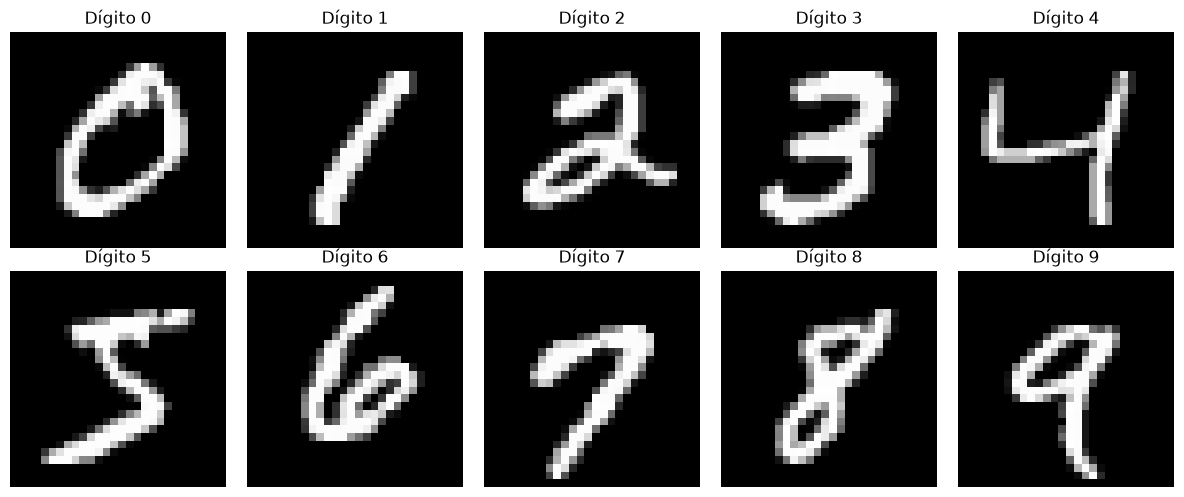

In [6]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

for digito in range(10):

    indice = np.where(
        y == digito
    )[0][0]

    imagem = X[indice].reshape(
        28,
        28
    )

    axes.flat[digito].imshow(
        imagem,
        cmap="gray"
    )

    axes.flat[digito].set_title(
        f"Dígito {digito}"
    )

    axes.flat[digito].axis(
        "off"
    )

plt.tight_layout()
plt.show()

Justificativa da Fase 1: o objetivo é conhecer a estrutura do dataset, verificar as classes, visualizar exemplos e confirmar que os pixels variam de 0 a 255. O trabalho pede exatamente dimensões, distribuição das classes, exemplos visuais e a explicação de 28×28 → 784.

## Estrutura dos dados do MNIST

O conjunto de dados **MNIST** é composto por imagens de dígitos manuscritos, representando os números de **0 a 9**. Cada imagem possui dimensões de **28 × 28 pixels** e está em escala de cinza.

### Intensidade dos pixels

Cada pixel da imagem é representado por um valor numérico entre **0 e 255**, indicando sua intensidade:

- **0** → pixel preto;
- **255** → pixel branco;
- **Valores intermediários** → diferentes tons de cinza.

Dessa forma, quanto maior o valor do pixel, mais clara é aquela região da imagem.

### Representação 28 × 28

Originalmente, cada imagem pode ser representada como uma matriz de **28 linhas por 28 colunas**:

**28 × 28 = 784 pixels**

Cada posição dessa matriz corresponde a um pixel da imagem e contém um valor entre 0 e 255.

### Vetorização das imagens

Para utilizar as imagens em muitos algoritmos de Machine Learning, a matriz bidimensional de **28 × 28 pixels** pode ser transformada em um vetor unidimensional.

Assim, os 784 pixels são organizados sequencialmente:

**28 × 28 → 784 features**

Portanto, cada imagem passa a ser representada por **784 características (features)**, em que cada feature corresponde à intensidade de um determinado pixel.

Exemplo simplificado:

Imagem 28 × 28:

    [[0,   0,  25, ...],
     [0, 120, 255, ...],
     [0,  80, 200, ...],
     ...]

Após a vetorização:

    [0, 0, 25, ..., 0, 120, 255, ..., 0, 80, 200, ...]

Dessa maneira, cada linha do conjunto de dados representa **uma imagem**, enquanto as **784 colunas de entrada representam os pixels** dessa imagem.

A variável alvo (*target*) corresponde ao **dígito representado na imagem**, podendo assumir valores inteiros de **0 a 9**.

### Resumo da estrutura

| Característica | Descrição |
|---|---|
| Dimensão original | 28 × 28 pixels |
| Número total de pixels | 784 |
| Intensidade dos pixels | 0 a 255 |
| 0 | Preto |
| 255 | Branco |
| Entrada do modelo | 784 features |
| Classes | Dígitos de 0 a 9 |
| Número de classes | 10 |

Essa transformação permite que algoritmos que trabalham com dados tabulares recebam cada imagem como um conjunto de **784 variáveis numéricas**, preservando as informações de intensidade dos pixels.